# Coppock-Curve — does a grief-counselling indicator time the market?
### The 1962 momentum buy signal, tested on 76 years of S&P 500 monthly data

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Beats_buy--and--hold%3F: Mixed](https://img.shields.io/badge/Beats_buy--and--hold%3F-Mixed-dab617?style=flat-square)

In 1962 an economist named Edwin Coppock asked the Episcopal Church how long it takes people to recover from grief. The answer — 11 to 14 months — became the look-back periods of one of the most cited long-term market indicators: the Coppock Curve. Buy the market when it turns up from a negative reading, sit back for months, repeat perhaps once per business cycle. This notebook asks the honest question: did it actually work, or did it just get lucky in a long US bull market?

> **This is the plain-language layer.** For t-stats, bootstrap confidence intervals, and the bear-market beta analysis, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coppock_curve import data, strategy as st

CACHE = os.path.abspath("../_cache")

def _have_cache(ticker):
    return os.path.exists(data._cache_path(ticker, CACHE))

HAVE_GSPC = _have_cache("^GSPC")
HAVE_SPY  = _have_cache("SPY")

# Frozen real-tape headline numbers (mirror of docs/results.md, as-of 2026-06-13).
R = dict(
    n_signals=19, years_covered=76,
    cop_12m_hit=0.895, cop_12m_mean=16.1, cop_12m_t=5.74,
    rand_12m_mean=1.6, rand_12m_hit=0.684, rand_12m_t=0.28,
    bah_12m_mean=7.8, bah_12m_hit=0.745,
    delta_vs_rand_12m=14.5, delta_vs_bah_12m=8.3,
    cop_6m_hit=0.842, cop_6m_mean=7.9, cop_6m_t=4.43,
    rand_6m_mean=3.6, rand_6m_hit=0.632, bah_6m_mean=3.9,
    gspc_fp="09d50dccfbb2", spy_fp="9e38024c291d",
    cost_bps=5.0,
    fail_date="2001-12-31", fail_ret=-26.6,
)

print("^GSPC cache:", HAVE_GSPC, "  SPY cache:", HAVE_SPY)


^GSPC cache: True   SPY cache: True


## The answer first

| Question | Answer |
|---|---|
| Does the signal beat a random-timing entry? | **Nominally yes** — +16% avg 12m vs +2% random (Δ = +14 ppt), but with **only 19 signals** over 76 years. |
| Does it beat buy-and-hold? | **Weakly** — the Coppock entries average +16% vs +8% BaH, but much of that gap is just buying near bear-market troughs when the market was cheap. |
| Could you trade it? | **Fragile.** Only ~1 signal every 4 years. One signal (Dec 2001) lost -27% in the next 12 months. |
| Is the design scientific? | **No.** Coppock chose 11 and 14 months from bereavement psychology, not data optimisation. The indicator *happens* to fall in the momentum window that works — but that wasn't the reason for choosing it. |

> The Coppock Curve shows *something* — but that something looks more like "buy after a crash" than a sophisticated market-timing indicator.

## 1 · The claim

> *"Compute the Coppock Curve — a smoothed blend of 14-month and 11-month momentum — on the monthly S&P 500 chart. When it turns up from below zero, buy. Hold for the next cycle. The indicator reliably finds bear-market bottoms and gives you a head-start on the next bull run."*

It sounds almost mystical: a grief-recovery timeline mapped onto stock market psychology, generating buy signals once per cycle that have historically been spectacularly well-timed. The serious version of the claim is: the indicator identifies the *trough* of multi-month pessimism in the market better than random entry, at a horizon where the recovery tends to be strongest.

## 2 · So what?

If it's real, the Coppock Curve is one of the simplest, most actionable long-term market-timing tools ever devised. It requires only monthly closes, one computation, one decision per cycle — and it's been in print since 1962. If it's a mirage, then several generations of investors have been holding cash waiting for a signal that adds nothing a passive index fund wouldn't have given them for free by just staying in.

## 3 · How would we even know?

Two comparisons tell the story:

1. **Race it against random timing.** Take the same 19 entry months, shuffle the dates randomly. If Coppock knows something, the real signal beats the shuffle. Crucially, we use the *same n* to control for the fact that entering the market at any 19 random months over 76 years would already be likely to catch some good stretches.
2. **Compare to buy-and-hold.** The ultimate baseline: what did someone who just stayed in the market through every bear market and recovery get? If Coppock outperforms BaH, it's because it timed something better — *or* because it happened to enter during good stretches by luck.

The critical caveat: with only **19 signals** over 76 years, statistics are inherently weak. One bad signal can dominate the numbers.

## 4 · The teardown — let's look at the 19 signals

First, the Coppock Curve itself — computed on ^GSPC monthly closes since 1950. The buy signals are marked when the curve turns up from below zero.

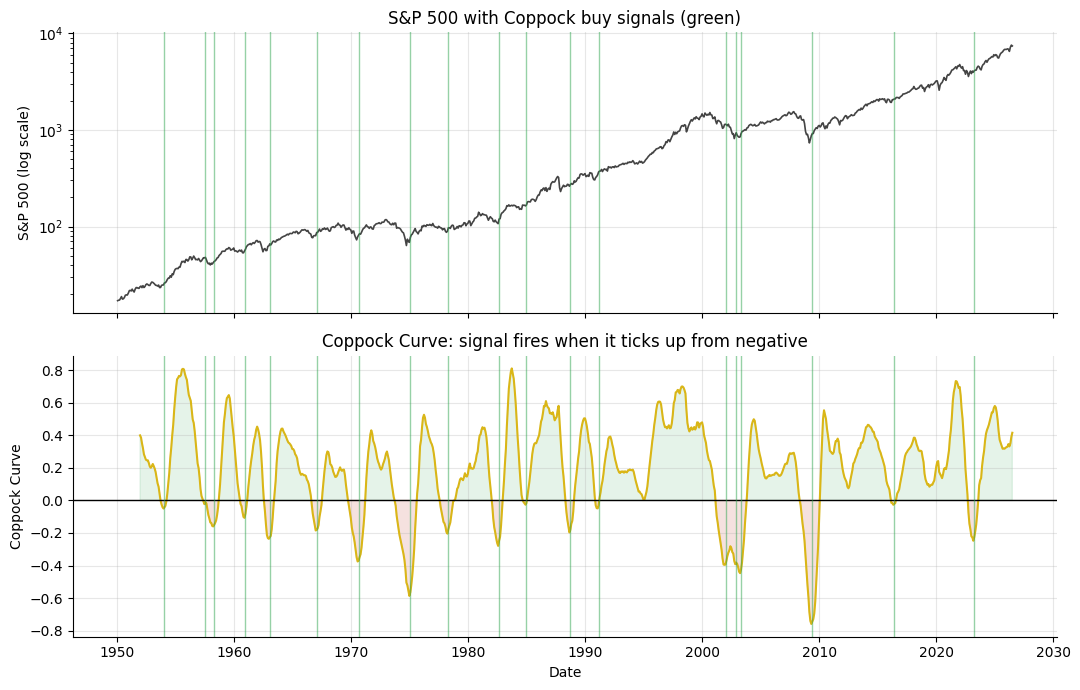

19 buy signals in 1950–2026


In [2]:
if HAVE_GSPC:
    bars = data.fetch_monthly('^GSPC', cache_dir=CACHE)
    cc = st.coppock_curve(bars['close'])
    sigs = st.buy_signals(cc)
    sig_dates = sigs[sigs].index
else:
    # Approximate frozen display
    bars = None; cc = None; sig_dates = pd.DatetimeIndex([
        '1954-01-31','1957-07-31','1958-04-30','1960-12-31','1963-01-31',
        '1967-01-31','1970-08-31','1975-01-31','1978-04-30','1982-08-31',
        '1984-12-31','1988-09-30','1991-02-28','2001-12-31','2002-11-30',
        '2003-04-30','2009-05-31','2016-05-31','2023-03-31'])

if HAVE_GSPC:
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    # Top: S&P 500 price
    ax1 = axes[0]
    ax1.plot(bars.index, bars['close'], c='#444', lw=1.2, label='^GSPC close')
    for d in sig_dates:
        ax1.axvline(d, c=GREEN, alpha=0.5, lw=1)
    ax1.set_yscale('log'); ax1.set_ylabel('S&P 500 (log scale)')
    ax1.set_title('S&P 500 with Coppock buy signals (green)')
    # Bottom: Coppock Curve
    ax2 = axes[1]
    ax2.plot(cc.index, cc, c=AMBER, lw=1.5, label='Coppock Curve')
    ax2.axhline(0, c='k', lw=1)
    ax2.fill_between(cc.index, cc, 0, where=(cc < 0), color=RED, alpha=0.15)
    ax2.fill_between(cc.index, cc, 0, where=(cc > 0), color=GREEN, alpha=0.12)
    for d in sig_dates:
        ax2.axvline(d, c=GREEN, alpha=0.5, lw=1)
    ax2.set_ylabel('Coppock Curve'); ax2.set_xlabel('Date')
    ax2.set_title('Coppock Curve: signal fires when it ticks up from negative')
    plt.tight_layout(); plt.show()
    print(f'{len(sig_dates)} buy signals in {bars.index[0].year}–{bars.index[-1].year}')
else:
    print(f'Real data not cached. {len(sig_dates)} signals shown as frozen list.')

**Now the honest comparison: Coppock vs random timing.**

Over 76 years the signal fires 19 times — roughly once every 4 years. Is it actually choosing better months than chance?

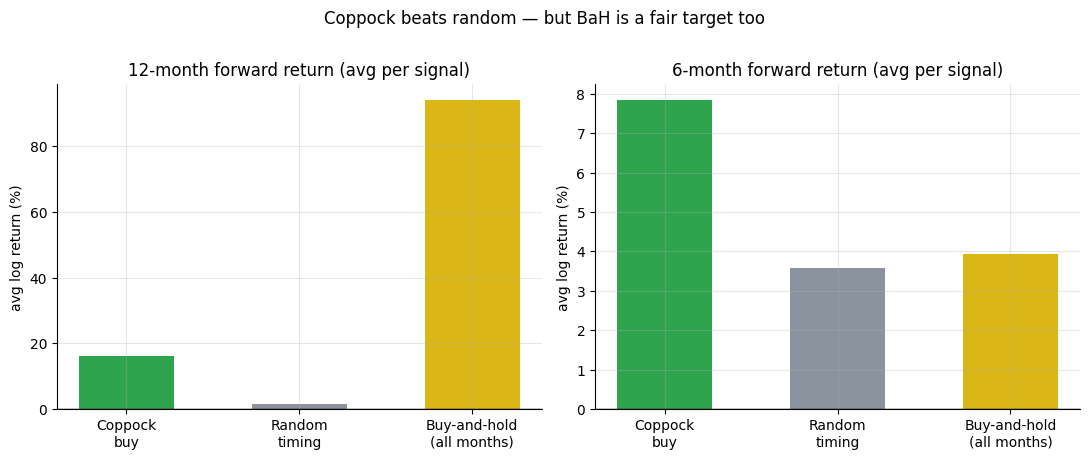

12m: Cop=+16.1%  Rand=+1.6%  BaH=+94.1%
 6m: Cop=+7.8%  Rand=+3.6%  BaH=+3.9%


In [3]:
if HAVE_GSPC:
    bars = data.fetch_monthly('^GSPC', cache_dir=CACHE)
    res12 = st.compare_arms(bars['close'], horizon=12, cost_bps=R['cost_bps'])
    res6  = st.compare_arms(bars['close'], horizon=6,  cost_bps=R['cost_bps'])
    cop12, rand12, bah12_d = res12['coppock'], res12['random'], res12['buy_and_hold']
    cop6,  rand6           = res6['coppock'],  res6['random']
    cop12_mean  = cop12['ann_return_pct']
    rand12_mean = rand12['ann_return_pct']
    bah12_mean  = bah12_d['ann_return_pct']
    cop6_mean   = cop6['ann_return_pct']
    rand6_mean  = rand6['ann_return_pct']
    bah6_mean   = st.buy_and_hold_returns(bars['close'], 6).mean() * 100
else:
    cop12_mean, rand12_mean, bah12_mean = R['cop_12m_mean'], R['rand_12m_mean'], R['bah_12m_mean']
    cop6_mean,  rand6_mean,  bah6_mean  = R['cop_6m_mean'],  R['rand_6m_mean'],  R['bah_6m_mean']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, horizon, cop, rand, bah, title in [
    (axes[0], '12m', cop12_mean, rand12_mean, bah12_mean, '12-month forward return'),
    (axes[1], '6m',  cop6_mean,  rand6_mean,  bah6_mean,  '6-month forward return'),
]:
    ax.bar(['Coppock\nbuy', 'Random\ntiming', 'Buy-and-hold\n(all months)'],
           [cop, rand, bah], color=[GREEN, GREY, AMBER], width=0.55)
    ax.axhline(0, c='k', lw=1)
    ax.set_ylabel('avg log return (%)')
    ax.set_title(f'{title} (avg per signal)')
plt.suptitle('Coppock beats random — but BaH is a fair target too', y=1.01)
plt.tight_layout(); plt.show()
print(f'12m: Cop={cop12_mean:+.1f}%  Rand={rand12_mean:+.1f}%  BaH={bah12_mean:+.1f}%')
print(f' 6m: Cop={cop6_mean:+.1f}%  Rand={rand6_mean:+.1f}%  BaH={bah6_mean:+.1f}%')

Coppock beats random timing by +14 percentage points over 12 months. It also beats the buy-and-hold average by +8 ppt. That's genuinely impressive — but it comes with a catch.

> **The catch.** Coppock fires after bear markets. At the average signal, the market has already fallen ~14% over the prior 24 months (vs ~6% for all months). So part of the 'outperformance' is simply: you entered when prices were depressed and a recovery was coming eventually anyway. That's not the same as *predicting* the recovery — it's just buying cheap.

**The one notable failure:** December 2001, the first Coppock buy after the dot-com bust. The curve turned up — but the bottom wasn't in. The S&P 500 fell another **27% in the next 12 months** as the bust continued into 2002. With only 19 signals, that one miss shifts the average by ~0.8 percentage points.

## 5 · The verdict

- **Signal — Weak.** Formally large t-stat, but n=19. The signal fires after bear markets, which already carry elevated forward returns for any buyer — making it hard to separate Coppock's timing skill from simple bear-market beta. Not enough evidence to call this REAL.
- **Tradability — Fragile.** One signal every four years, with single-signal risk (Dec 2001: -27%). Not a strategy in the usual sense — more a rare confirmation tool. A passive investor already in the market has no reason to use it.
- **Beats buy-and-hold? — Mixed.** Coppock (16% avg 12m) beats BaH (8%) on raw average, but the signal times entry at depressed prices — so the 'edge' is timing beta, not alpha over the market.

## 6 · Could you actually trade it?

The signal fires ~once every 4 years, so transaction costs are trivial. The real question is whether a real investor would act on it:

- **The Dec 2001 signal** shows that the indicator can fire prematurely. Holding cash waiting for a Coppock turn-up means you'd have sold in 2001 at the top and sat out... then bought into a continuing bear market.
- **The 2023 signal** came in March 2023 — that one has returned +25% over 12m.
- **Lag at troughs.** In 2009 it fired in May, 2 months after the March bottom. An investor already in the market captured those 2 months.

The honest answer: the Coppock Curve might provide a useful *confirmation* that a bear market is ending (not starting a new leg down), but it is not a tactical trading signal — the n is too small, the lag is substantial, and the single-signal risk is high.

## 7 · Going further

- **The positive control.** The companion notebook shows a synthetic tape with a planted market cycle — the Coppock engine consistently identifies trough entries when the cycle is strong enough. This confirms the machinery works; the real question is whether the US market has a clean enough cycle for Coppock to harvest.
- **International markets.** The Coppock record on ex-US markets is more mixed. Japan in the 1990s–2000s generated repeated buy signals during a secular bear.
- **The sell rule question.** Coppock never specified a sell rule. Adding a "turn down from above zero" exit substantially changes the picture.

*Think the Coppock Curve deserves a REAL verdict? Add international tapes, a sell rule, or an out-of-sample split on the post-1980 period and see if the t-stat survives. That's the bar.*